In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# -------------------------------------------------
# Create FrozenLake Environment
# -------------------------------------------------

# Write your code here
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True)
num_states = env.observation_space.n
num_actions = env.action_space.n

In [3]:
# -------------------------------------------------
# Hyperparameters
# -------------------------------------------------
num_episodes = 20000
max_steps = 100

alpha = 0.1          # learning rate
gamma = 0.99         # discount factor

epsilon = 1.0        # starting exploration rate
epsilon_min = 0.01
epsilon_decay = 0.0005   # exponential decay rate

In [4]:
# -------------------------------------------------
# Initialize Q-table
# -------------------------------------------------

# Write your code here
Q = np.zeros((num_states, num_actions))

# -------------------------------------------------
# Epsilon-Greedy Action Selection
# -------------------------------------------------

# Write your code here
rng = np.random.default_rng(42)

def choose_action(state, epsilon):
    if rng.random() < epsilon:
        return env.action_space.sample()
    # random tie-breaking among the maximal action values
    best = np.flatnonzero(Q[state] == Q[state].max())
    return int(rng.choice(best))

In [5]:
# -------------------------------------------------
# Q-Learning Training
# -------------------------------------------------

# Write your code here
episode_rewards = []

for episode in range(num_episodes):
    state, info = env.reset()
    total_reward = 0.0

    for step in range(max_steps):
        action = choose_action(state, epsilon)
        next_state, reward, terminated, truncated, info = env.step(action)

        # Q-learning update
        if terminated:
            target = reward
        else:
            target = reward + gamma * np.max(Q[next_state])

        Q[state, action] += alpha * (target - Q[state, action])

        state = next_state
        total_reward += reward

        if terminated or truncated:
            break

    # decay exploration
    epsilon = epsilon_min + (1.0 - epsilon_min) * np.exp(-epsilon_decay * episode)

    episode_rewards.append(total_reward)

episode_rewards = np.array(episode_rewards)

# derive the value function and greedy policy from Q
state_values = np.max(Q, axis=1)
learned_policy = np.argmax(Q, axis=1)

In [6]:
# -------------------------------------------------
# Display Functions
# -------------------------------------------------

def print_value_function(values):
    print("\nEstimated State-Value Function:")
    print(np.round(values.reshape(4, 4), 3))


def print_policy(policy):
    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [action_symbols[action] for action in policy]
    ).reshape(4, 4)

    print("\nLearned Policy:")
    print(policy_grid)


In [7]:
# -------------------------------------------------
# Output
# -------------------------------------------------

print("\nFinal Q-table:")
print(np.round(Q, 3))

print_value_function(state_values)
print_policy(learned_policy)

average_reward = np.mean(episode_rewards[-1000:])
print("\nAverage reward over last 1000 episodes:", average_reward)


Final Q-table:
[[0.491 0.485 0.484 0.486]
 [0.409 0.245 0.228 0.459]
 [0.404 0.423 0.404 0.445]
 [0.301 0.258 0.17  0.435]
 [0.514 0.376 0.387 0.317]
 [0.    0.    0.    0.   ]
 [0.321 0.109 0.195 0.135]
 [0.    0.    0.    0.   ]
 [0.385 0.437 0.492 0.568]
 [0.461 0.623 0.441 0.358]
 [0.642 0.413 0.393 0.312]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.465 0.543 0.718 0.415]
 [0.684 0.866 0.748 0.761]
 [0.    0.    0.    0.   ]]

Estimated State-Value Function:
[[0.491 0.459 0.445 0.435]
 [0.514 0.    0.321 0.   ]
 [0.568 0.623 0.642 0.   ]
 [0.    0.718 0.866 0.   ]]

Learned Policy:
[['L' 'U' 'U' 'U']
 ['L' 'L' 'L' 'L']
 ['U' 'D' 'L' 'L']
 ['L' 'R' 'D' 'L']]

Average reward over last 1000 episodes: 0.7


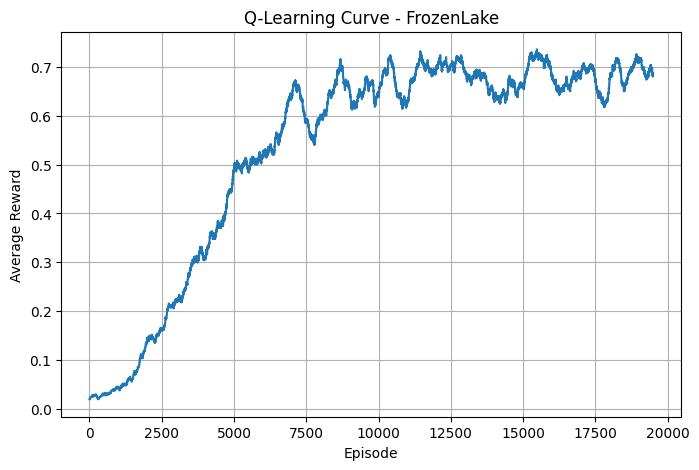

In [8]:
# -------------------------------------------------
# Plot Learning Curve
# -------------------------------------------------

window = 500

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 5))
plt.plot(moving_average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Q-Learning Curve - FrozenLake")
plt.grid(True)
plt.show()

env.close()